# PHYS3116 Tutorial 4: Curve Fitting and Star Formation

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from scipy import stats
from scipy.signal import find_peaks

## Worked Example: Linear Curve Fitting

In [2]:
# Randomly Generate Data
gradient = 25
x = np.arange(0, 100, 1)
y = gradient * x + 1000 * np.random.rand(100)

df = pd.DataFrame({
    'x': x,
    'y': y,
})

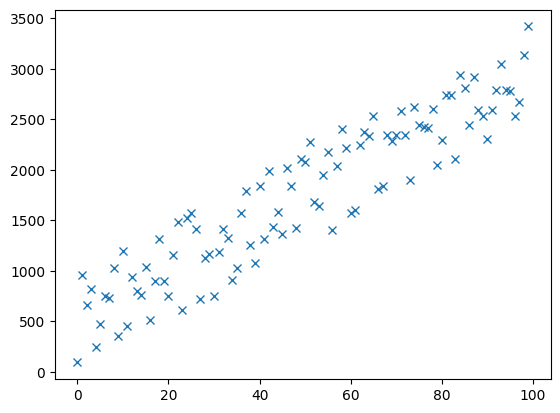

In [3]:
plt.plot(
    df['x'],
    df['y'],
    'x'
)

Linear Regression yields the following parameters:
- `slope`
- `intercept`
- `rvalue`
- `pvalue`
- `stderr`: standard error of slope
- `intercept_stderr`: standard error of intercept


High `rvalue` (magnitude between 0.7 and 0.1) indicates strong linear relationship.  
`pvalue < 5%` is considered strong evidence for a linear fit (i.e probability of getting such an extreme outcome is less than 5%)

In [11]:
def lin(x, m, c):
    return m * x + c

popt, pcov = scipy.optimize.curve_fit(lin, df['x'], df['y'])

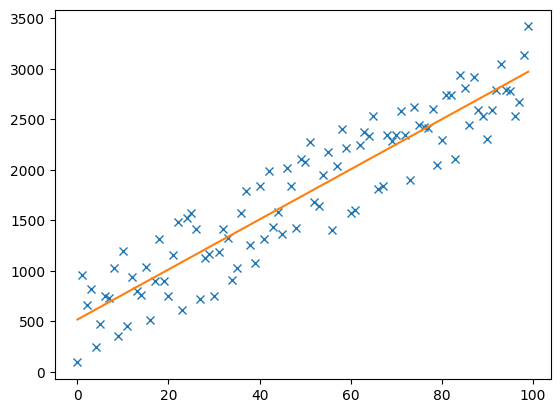

In [14]:
xfit = np.arange(0, 100)
yfit = popt[0] *xfit +popt[1]

plt.plot(
    df['x'],
    df['y'],
    'x'
)

plt.plot(xfit, yfit)

In [4]:
# Fit a linear curve
result = stats.linregress(x, y)
print(result)
print(f'Line has equation y = ({result.slope:.2f} +- {result.stderr:.2f}) * x + ({result.intercept:.2f} +- {result.intercept_stderr:.2f})')
print(f'Result has R-value of {result.rvalue:.2f} and p-value of {result.pvalue:.2e}')

LinregressResult(slope=np.float64(24.779546002404867), intercept=np.float64(516.8883065763628), rvalue=np.float64(0.9273841139743401), pvalue=np.float64(1.2338188825015722e-43), stderr=np.float64(1.0097656970491253), intercept_stderr=np.float64(57.86142476731788))
Line has equation y = (24.78 +- 1.01) * x + (516.89 +- 57.86)
Result has R-value of 0.93 and p-value of 1.23e-43


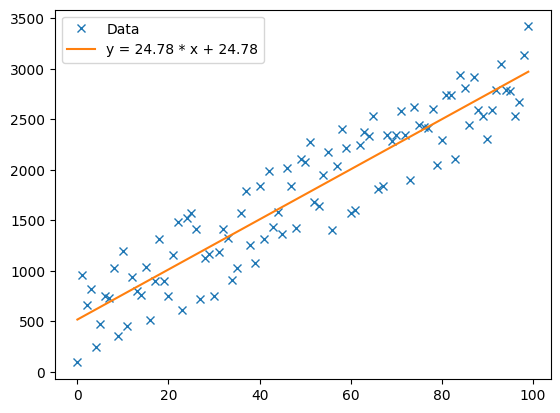

In [5]:
plt.plot(
    df['x'],
    df['y'],
    'x',
    label='Data'
)
# Adding LOB to graph
plt.plot(
    x, result.slope * x + result.intercept,
    label=f'y = {result.slope:.2f} * x + {result.slope:.2f}'
)
plt.legend()

## Worked Example: Star Formation Rate as a function of stellar mass and age.

In [15]:
data = pd.read_csv('PHYS3116_Week4_Tutorial_Data.csv')
data = data[(data['alpha_re'] > -99) & (data['z_re'] > -99)]

<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
C:\Users\jrh28\AppData\Local\Temp\ipykernel_34968\46364962.py:10: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Log of Stellar Mass ($\log M_\odot$)')


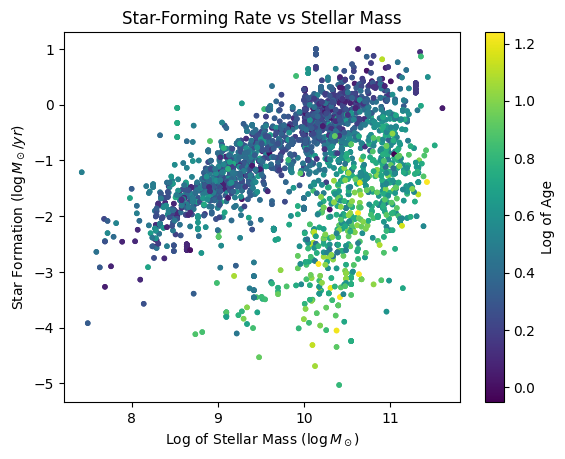

In [8]:
plt.scatter(
    data['mstar'],
    np.log10(data['sfr_re']),
    c=np.log10(data['age_re']),
    marker='.'
)
cbar = plt.colorbar()

plt.title(r'Star-Forming Rate vs Stellar Mass')
plt.xlabel('Log of Stellar Mass ($\log M_\odot$)')
plt.ylabel(r'Star Formation ($\log M_\odot / yr$)')
cbar.set_label(r'Log of Age')

<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
C:\Users\jrh28\AppData\Local\Temp\ipykernel_34968\1680812270.py:10: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Log of Stellar Mass ($\log M_\odot$)')


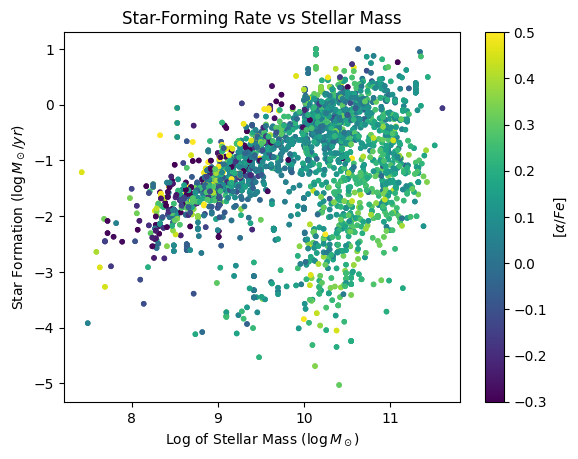

In [9]:
plt.scatter(
    data['mstar'],
    np.log10(data['sfr_re']),
    c=data['alpha_re'],
    marker='.'
)
cbar = plt.colorbar()

plt.title(r'Star-Forming Rate vs Stellar Mass')
plt.xlabel('Log of Stellar Mass ($\log M_\odot$)')
plt.ylabel(r'Star Formation ($\log M_\odot / yr$)')
cbar.set_label(r'$[\alpha / Fe]$')

# Exercises

## 1) Star Formation Rates + Linear Regression
#### a) Does morphology affect the star-formation rate? (Plot Star Formation rate vs stellar mass for ellipticals (Type = 0, 0.5) and Spirals (Type = 2,  2.5, 3)
#### b) Using `stats.linregress`, find star formation rate as a function of mass for spiral galaxies, i.e. find values `A` and `B` in `star formation rate = A log (stellar mass) + B`. Is the relationship strong?

Data for this weeks tutorial comes from SAMI:
- `sami_dr3.EmissionLine1compDR3`
    - `sfr_re`: Star formation rate in RE aperture 
- `sami_dr3.SSPAperturesDR3`
    - `alpha_re`: SSP alpha abundance within the RE aperture
    - `z_re`: SSP metallicity within the RE aperture
- `sami_dr3.VisualMorphologyDR3`
    - `type`: Morphological Type (0=E; 0.5=E/S0; 1=S0; 1.5=S0/Early-spiral; 2=Early-spiral; 2.5=Early/Late spiral; 3=Late spiral; 5=?; -9=no agreement)    
- `sami_dr3.InputCatClustersDR3` and `sami_dr3.InputCatGAMADR3`:
    - `mstar`: Logarithm of stellar mass

In [16]:
data = pd.read_csv('PHYS3116_Week4_Tutorial_Data.csv')
data = data[(data['alpha_re'] > -99) & (data['z_re'] > -99)]
data = data.dropna(subset=['mstar', 'sfr_re'])

In [23]:
total = len(data)
print(total)
emask = data["type"] < 1
smask = (data["type"] > 1) & (data["type"] < 4)
esum = np.sum(emask)
ssum = np.sum(smask)
print("Number of elements in emask:", esum)
print("Number of elements in smask:", ssum)

5250
Number of elements in emask: 768
Number of elements in smask: 3874


       catid  mstar   ellip  type  alpha_re   z_re    age_re    sfr_re
104   301799   9.88  0.6073  -9.0     0.014 -0.095  2.184691  0.096190
105   301799   9.88  0.6073  -9.0     0.014 -0.095  2.184691  0.096190
842   504922  10.02  0.7838  -9.0     0.085 -0.156  2.750363  0.246319
843   504922  10.02  0.7838  -9.0     0.085 -0.156  2.750363  0.246319
1156  239292  10.00  0.4923   0.5     0.065  0.086  1.546643  0.073539
1157  239292  10.00  0.4923   0.5     0.065  0.086  1.546643  0.076678
1158  239292  10.00  0.4923   0.5     0.065  0.066  1.546643  0.073539
1159  239292  10.00  0.4923   0.5     0.065  0.066  1.546643  0.076678
1160  239292  10.00  0.4923   0.5     0.065  0.086  1.546643  0.073539
1161  239292  10.00  0.4923   0.5     0.065  0.086  1.546643  0.076678


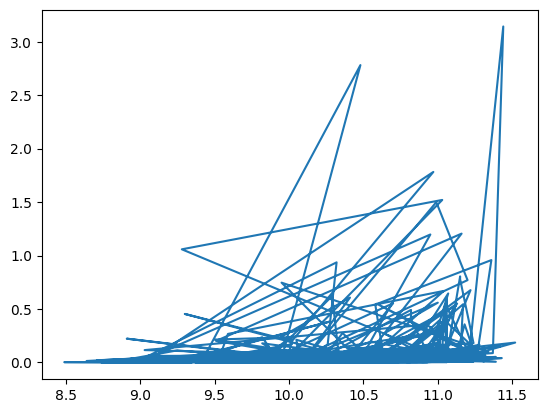

In [27]:
# 1) a) 
print(data[emask].head(10))
plt.plot(
    data[emask]['mstar'],
    data[emask]['sfr_re'],
)

In [ ]:
# 1) b) 

## 2) Spectra 
#### a) Compute the red-shift of this particular galaxy given that the Balmer Alpha line is 6562.8 Angstrom in the rest frame. Identify any other relevant peaks. 
#### b) Transforming your graph in 2)a) from a redshifted wavelength scale to the rest frame wavelength scale.

Recall that:
$$
    z = \frac{\Delta \lambda}{\lambda_0}
$$

where $\lambda_0$ is rest frame wavelength and $\Delta \lambda = \lambda - \lambda_0$

Note for the data:
- Wavelength is in $Angstrom$
- Flux is in $10^{-20} Angstrom^-1 cm^-2 erg s^{-1}$

This link may be useful for identifying spectra [Galaxy Spectra](http://astronomy.nmsu.edu/nicole/teaching/ASTR505/lectures/lecture26/slide01.html)

In [2]:
mysterious_galaxy = pd.read_csv('mysterious_galaxy.csv')
mysterious_galaxy['flux'] = np.where(mysterious_galaxy['flux'] == 0, np.nan, mysterious_galaxy['flux'])

In [5]:
peaks, _ = find_peaks(mysterious_galaxy['flux'], prominence=10000)
halpha_wavelength = mysterious_galaxy['wavelength'][peaks].iloc[0]
halpha_flux = mysterious_galaxy['flux'][peaks].iloc[0]

In [6]:
halpha_wavelength

8472.5

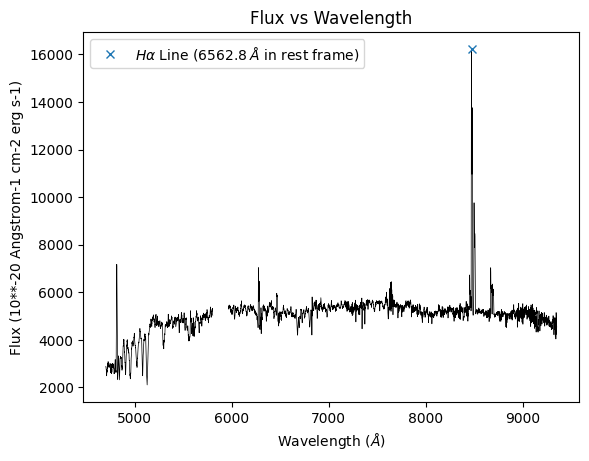

In [4]:
plt.plot(
    mysterious_galaxy['wavelength'],
    mysterious_galaxy['flux'],
    'k-',
    linewidth='0.5'
)

plt.plot(
    halpha_wavelength,
    halpha_flux,
    'x',
    label=r'$H\alpha$ Line ($6562.8 \; \AA$ in rest frame)'
)

plt.title('Flux vs Wavelength')
plt.xlabel('Wavelength ($\AA$)')
plt.ylabel('Flux (10**-20 Angstrom-1 cm-2 erg s-1)')
plt.legend()

In [ ]:
# 2) a)

In [ ]:
# 2) b)